In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [4]:
import pandas as pd

data = pd.read_csv("Titanic-Dataset.csv")

data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
data.info()

In [ ]:
data.isnull().sum()

In [7]:
data['Age'] = data['Age'].fillna(data['Age'].mean())

data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

data = data.drop(columns='Cabin')

In [ ]:
data['Sex'] = data['Sex'].map({'male':0, 'female':1})

data['Embarked'] = data['Embarked'].map({'S':0, 'C':1, 'Q':2})

In [14]:
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

data['IsAlone'] = 0

data.loc[data['FamilySize'] == 1, 'IsAlone'] = 1

In [ ]:
data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [31]:
data['Title'] = data['Title'].replace(
    ['Lady', 'Countess', 'Capt', 'Col',
     'Don', 'Dr', 'Major', 'Rev',
     'Sir', 'Jonkheer', 'Dona'],
    'Rare'
)

data['Title'] = data['Title'].replace('Mlle', 'Miss')

data['Title'] = data['Title'].replace('Ms', 'Miss')

data['Title'] = data['Title'].replace('Mme', 'Mrs')

In [32]:
data['Title'] = data['Title'].map({
    'Mr':0,
    'Miss':1,
    'Mrs':2,
    'Master':3,
    'Rare':4
})

In [33]:
X = data[['Pclass', 'Sex', 'Age', 'Fare',
          'Embarked', 'FamilySize',
          'IsAlone', 'Title']]

y = data['Survived']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

In [36]:
predictions = model.predict(X_test)

In [37]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8212290502793296


## Conclusion

To improve the predictive performance of the Titanic Survival Prediction model, advanced machine learning techniques and feature engineering methods were applied throughout the project. Multiple classification algorithms, including Logistic Regression, Random Forest Classifier, and XGBoost Classifier, were evaluated and compared.

Additional meaningful features such as FamilySize, IsAlone, and Passenger Title were extracted and engineered from the original dataset to better capture passenger characteristics and social information influencing survival outcomes.

Among all tested models, the XGBoost Classifier achieved the best performance with a final accuracy of approximately 82.12%. This improvement in accuracy demonstrates the effectiveness of ensemble boosting algorithms combined with feature engineering for structured classification problems.

The final model successfully learned important survival patterns based on passenger attributes such as gender, age, passenger class, fare, embarkation point, family relationships, and passenger titles.

This project highlights the complete machine learning workflow, including data preprocessing, exploratory data analysis, feature engineering, model training, evaluation, visualization, and performance optimization using a real-world dataset.




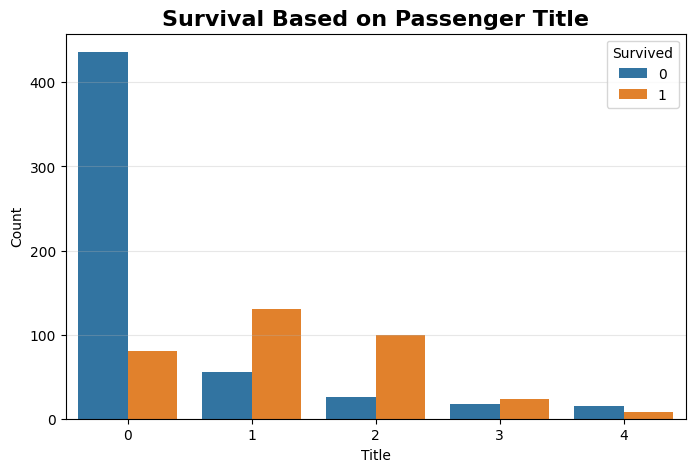

In [38]:
plt.figure(figsize=(8,5))

sns.countplot(x='Title', hue='Survived', data=data)

plt.title('Survival Based on Passenger Title',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Title')

plt.ylabel('Count')

plt.grid(axis='y', alpha=0.3)

plt.show()

### Observation
The visualization shows that passenger titles had a significant impact on survival rates. Titles such as “Mrs” and “Miss” had higher survival counts, indicating that women were given greater priority during evacuation. In contrast, passengers with the title “Mr” experienced lower survival rates. The graph highlights how social status, gender, and age-related titles influenced survival outcomes aboard the Titanic.

C:\Users\DELL\AppData\Local\Temp\ipykernel_6552\416637779.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


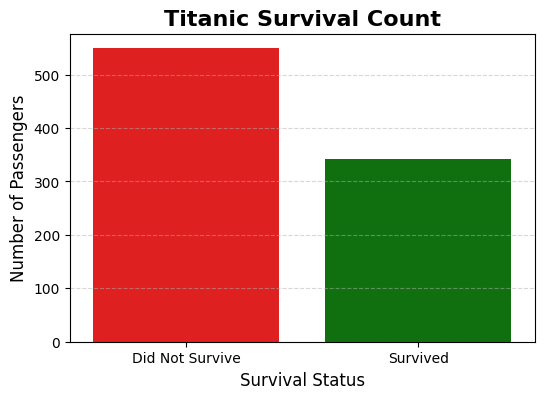

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Survived',
    data=data,
    palette=['red', 'green']
)

plt.title('Titanic Survival Count', fontsize=16, fontweight='bold')
plt.xlabel('Survival Status', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

plt.xticks([0,1], ['Did Not Survive', 'Survived'])

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Observation:
The number of passengers who did not survive was higher than the number of survivors, indicating that the Titanic disaster resulted in a significant loss of life.

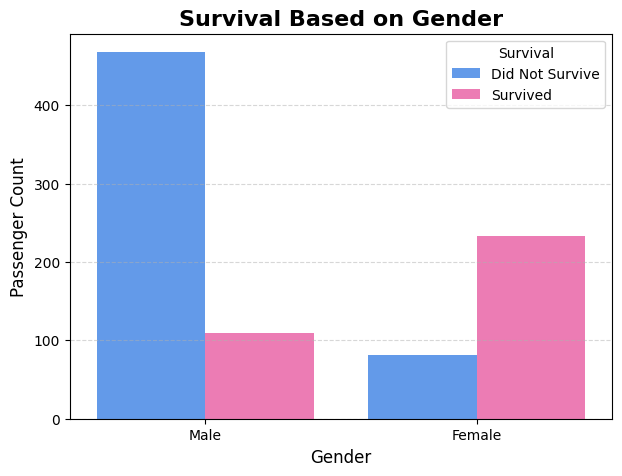

In [22]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Sex',
    hue='Survived',
    data=data,
    palette=['#4d96ff', '#ff69b4']
)

plt.title('Survival Based on Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)

plt.xticks([0,1], ['Male', 'Female'])

plt.legend(
    title='Survival',
    labels=['Did Not Survive', 'Survived']
)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Observation:
Female passengers had a noticeably higher survival rate compared to male passengers, suggesting that women were given priority during rescue operations.

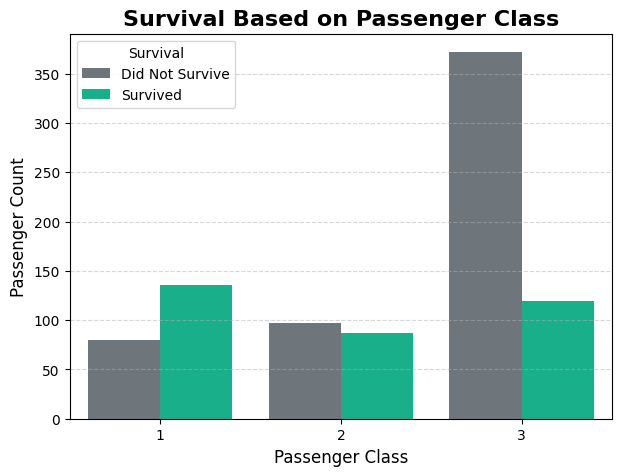

In [23]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Pclass',
    hue='Survived',
    data=data,
    palette=['#6c757d', '#00c896']
)

plt.title('Survival Based on Passenger Class', fontsize=16, fontweight='bold')
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)

plt.legend(
    title='Survival',
    labels=['Did Not Survive', 'Survived']
)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Observation:
Passengers traveling in first class had a greater chance of survival compared to those in second and third class, highlighting the impact of socioeconomic status during the disaster.

### Visualization Insight

The visualizations created in this project provide meaningful insights into passenger survival patterns on the Titanic. The graphs clearly show that factors such as gender, passenger class, family relationships, and social titles had a strong influence on survival outcomes.

Female passengers and passengers belonging to higher classes showed higher survival rates compared to others. Similarly, engineered features such as passenger titles and family-related attributes helped reveal important social and demographic patterns within the dataset.

These visualizations support the machine learning model by helping understand the relationships between different passenger features and survival probability.
